## Whisper-Persian transcription for explosive-media-footage
#### 981 videos, 6 parallel workers

In [ ]:
#importing whisper-persian fine-tuned model by @Paulwalker4884 for transcription of the persian audio in the videos.
from transformers import WhisperForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

#runnig it locally
device = "cpu"

#specifying the base_model and the processor for the fine-tuned model
base_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base").to(device)
processor = AutoProcessor.from_pretrained("Paulwalker4884/whisper-persian")

lora_config = LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1, bias="none", inference_mode=True,
)
model = get_peft_model(base_model, lora_config)
adapter_path = hf_hub_download("Paulwalker4884/whisper-persian", "adapter_model.safetensors")
adapter_weights = load_file(adapter_path)
model.load_state_dict(adapter_weights, strict=False)
model.eval()
print("Model loaded. Imports verified.")

Running on: cpu


/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Model loaded. Imports verified.


#### Parallel Whisper-Persian Transcription                                                                        
                                                                                                                     
  Runs `transcribe_parallel.py` — a standalone script that transcribes audio from all 981 videos in
  and writes the Persian transcriptions into the 'audio_transcription_persian' column.                                                                                    
                                                                                          
 
  - Spawning 6 parallel workers, each worker loads its own copy of openai/whisper-base with the                                                 
  [Paulwalker4884/whisper-persian](https://huggingface.co/Paulwalker4884/whisper-persian) LoRA adapter               
  - For each video: extracts audio via ffmpeg → resamples to 16kHz mono → splits into 28-second chunks → feeds each chunk to Whisper and joins the output                                                                                 
  - Partial results are saved to `transcription_chunks/worker_*.json` after every video, so progress survives
  interruptions                                                                                              
  - Final results are merged back into the CSV when all workers finish

In [24]:
#running the transcription script and merging the results back into the CSV

%cd /Users/towcenter/Desktop/explosive-media-footage                                                               
!~/.pyenv/versions/3.11.14/bin/python transcribe_parallel.py

/Users/towcenter/Desktop/explosive-media-footage
981 videos to transcribe with 6 workers
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_downl

In [ ]:
#checking if the rows have been transcribed successfully

import pandas as pd                                                                                                                                                                                                                        
df = pd.read_csv("explosive_media_messages.csv")                                                                                                                                                                                           
filled = df["audio_transcription_persian"].dropna().astype(str).str.strip().replace("", None).dropna().count()                                                                                                                             
                                                                                                                                                                                                       
df[["media_filename", "audio_transcription_persian"]].dropna().head(5)

,media_filename,audio_transcription_persian
0,2025-12-31_001.mp4,I'm...
3,2026-01-01_002.mp4,این نوخد بسیار بسیار حصاسی چا توش مانان ایرندر...
4,2026-01-01_003.mp4,you you
6,2026-01-01_005.mp4,اگه ایتراز در چا هرچو بها بیتیت هر جا ان انت ا...
10,2026-01-01_008.mp4,Music you


#### after the transcription script ran i realized there were a bunch of entries for mp4 files which were transcribed in (1) a different language, (2) showed error
#### i also wondered whether this was because the fine-tuned whisper model is not so fine or if the transcription script caused these errors
#### this was the breakdown of the 981 videos:

 #### Breakdown of the 981 results:                                                                                                                                       
  - 40.6% — repetitive hallucinations (phrase looped dozens of times)                                                                                                 
  - 29.1% — wrong language (English, Spanish, etc.)                                                                                                                   
  - 15.3% — Persian but heavily garbled                                                                                                                               
  - 10.8% — filler/noise ("you", "Music", single words)                                                                                                               
  - 4.3% — other scripts (Hebrew, Russian, Korean)     
  - 0.7% — ffmpeg errors           

In [29]:
#running the second version of the transcription script

%cd /Users/towcenter/Desktop/explosive-media-footage                                                                                                                
!~/.pyenv/versions/3.11.14/bin/python transcribe_parallel_v2.py

/Users/towcenter/Desktop/explosive-media-footage
Added audio_transcription_persian_v2 column to CSV
981 videos to transcribe with 6 workers
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If

In [ ]:
#automatically triggering the english translation script after the second version of the transcription script runs

!~/.pyenv/versions/3.11.14/bin/python /Users/towcenter/Desktop/explosive-media-footage/translate_audio.py

In [31]:
#fuck it lets chain it together and go to bed ughhhhhh

%cd /Users/towcenter/Desktop/explosive-media-footage                                                                                                                
!~/.pyenv/versions/3.11.14/bin/python transcribe_parallel_v2.py && ~/.pyenv/versions/3.11.14/bin/python translate_audio.py

/Users/towcenter/Desktop/explosive-media-footage
981 videos to transcribe with 6 workers
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/towcenter/.pyenv/versions/3.11.14/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_downl

In [ ]:
#vetting the transcriptions part 1: checking for ffmpeg errors                                                                                                                                              
                                                                                                                                  
df = pd.read_csv("explosive_media_messages.csv")                                                                                                                  
                                                                                                                                                                      
v2_errors = df[df["audio_transcription_persian_v2"].astype(str).str.startswith("[ERROR")][                                                                          
      ["media_filename", "audio_transcription_persian_v2"]                                                                                                            
  ]                                                                                                                                                                   
print(f"{len(v2_errors)} errors")                             
v2_errors

7 errors


,media_filename,audio_transcription_persian_v2
14,2026-01-01_012.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
143,2026-01-03_002.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
504,2026-01-08_019.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
673,2026-01-29_036.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
901,2026-02-02_002.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
2248,2026-02-23_006.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."
2345,2026-02-24_036.mp4,"[ERROR: Command '['ffmpeg', '-y', '-i', 'scrap..."


In [36]:
#vetting the transcriptions part 1: checking for hallucinations

def is_repetitive(text):                                                          
      if not isinstance(text, str) or not text.strip():                             
          return False                                                              
      words = text.split()                                                          
      if len(words) > 10:                                                           
          return len(set(words)) / len(words) < 0.3
      return False                                                                  
                                                                
repetitive = df[df["audio_transcription_persian_v2"].apply(is_repetitive)][       
      ["media_filename", "audio_transcription_persian_v2", "audio_transcription_persian",     
  "audio_transcription_english"]                                                    
  ]                                                             
print(f"{len(repetitive)} repetitive hallucinations")                             
repetitive.head(10)                                                                                                                                             


521 repetitive hallucinations


,media_filename,audio_transcription_persian_v2,audio_transcription_persian,audio_transcription_english
3,2026-01-01_002.mp4,این نوخد بسیار بسیار حصاسی چا توشه نان ایرندر ...,این نوخد بسیار بسیار حصاسی چا توش مانان ایرندر...,[Heavily garbled transcription - unable to ext...
4,2026-01-01_003.mp4,دیگیمی دیگیمی دیگیمی دیگیمی دیگیمی دیگیمی دیگی...,you you,[Unintelligible repetition]
10,2026-01-01_008.mp4,بایدیم که از این ایشه این ایشه این ایشه این ای...,Music you,[Heavily garbled transcription - unable to ext...
12,2026-01-01_010.mp4,داهاد السنه دا مدیوه مل عسله داهاد السنه دا مد...,لا تسلد مكيوم العسلد لا لا تسلد مكيوم العسلد ل...,[Heavily garbled transcription - unable to ext...
22,2026-01-01_020.mp4,درستی که از از از از از از از از از از از از ا...,I'm going to go to the next station.,[This segment contains only repeated phonetic ...
24,2026-01-01_022.mp4,البه ادام میخونه.البه ادام میخونه.البه ادام می...,על הבא אידם מכונה על הבא אידם מכונה על הבא איד...,He continues to read. He continues to read. He...
26,2026-01-01_024.mp4,بماگه فلانی خوبه منه باید بزریت. ما بر اصاز نظ...,بمگه فلانی خوبه منه بید بزاریت. مبه رساس نظر ک...,"If such and such is good, I must pursue it. Fr..."
30,2026-01-01_028.mp4,موزردیم موزردیم موزردیم موزردیم موزردیم موزردی...,مجا اپارک موسال لسیی موطاری بون که سفره سرکیش ...,[This segment contains only repeated phonetic ...
37,2026-01-01_035.mp4,بایدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدید...,МУЗЫКАЛЬНАЯ ЗАСТАВКА you,[This segment contains only repeated phonetic ...
52,2026-01-01_050.mp4,درستی درستی درستی درستی درستی درستی درستی درست...,The,"Correct, correct, correct, correct, correct, c..."


#### at the end of this process, the status update showed me there were at least 7 rows with ffmpeg errors, and 521 rows with 'repetitive hallucinations' in V2, but only 2 rows where the wrong language was used. 

#### as far as the transcription was concerned, it was executed correctly in 630 out of 981 cases, but in 297 cases it was marked unintelligible, and in 46 cases there were translation failures. 

#### to fix these errors, i decided to reboot the dashboard and address them manually, before moving on to the next stage of building the golden dataset. 

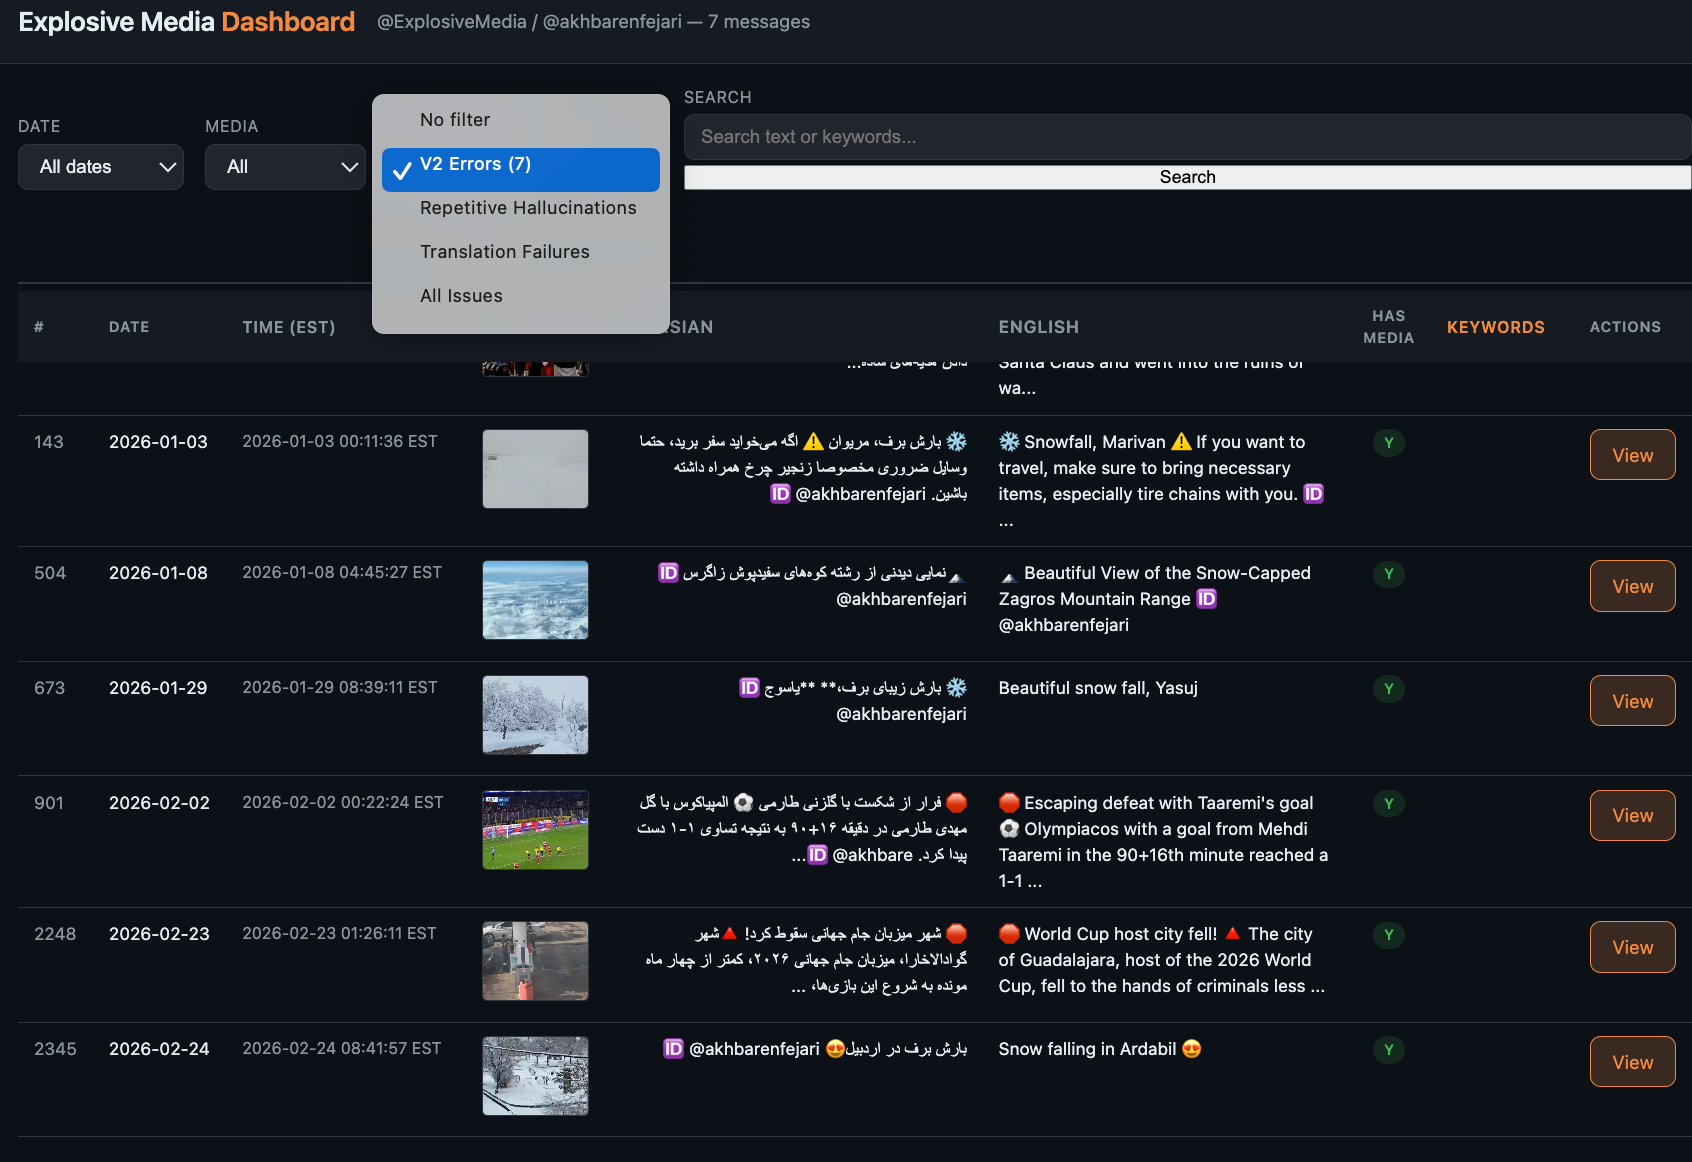

####  in all ffmpeg errors, the post did not include transcribable audio, but instead included images or videos of weather, the Iranian landscape, or sports coverage (Football)

In [40]:
#moving on to the repetitive hallucinations: I tried to comb through some of them manually, 
#to get a sense of what was causing the transcriptions to go awry, and it seems like the model is getting confused by the presence of music in the background, or trying to transcribe untranscribable ambeint sounds because these were videos of the weather
#looking at this content, i realized a significant majority of it is videos of the weather

def is_repetitive(text):                                                                                  
      if not isinstance(text, str) or not text.strip():
          return False                                                                                      
      words = text.split()                                      
      if len(words) > 10:                                                                                   
          return len(set(words)) / len(words) < 0.3             
      return False                             

rep = df[df["audio_transcription_persian_v2"].apply(is_repetitive)].copy()                                
   
# filter out weather/rain/snow videos                                                                     
weather_words = r'(?i)\b(weather|rain|snow)\b'                
weather_rows = rep[rep["message_text_english"].astype(str).str.contains(weather_words, na=False)]         
non_weather = rep[~rep["message_text_english"].astype(str).str.contains(weather_words, na=False)]         
                                                                                                            
print(f"Total repetitive: {len(rep)}")                                                                    
print(f"Weather/rain/snow (removing): {len(weather_rows)}")                                               
print(f"Remaining to fix: {len(non_weather)}")                
                                                                                                            
non_weather[["media_filename", "message_text_english", "audio_transcription_persian_v2"]].head(10)



Total repetitive: 521
Weather/rain/snow (removing): 17
Remaining to fix: 504


/var/folders/jw/4__g8_4s7812q133hmwkrny40000gn/T/ipykernel_34120/4035706017.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  weather_rows = rep[rep["message_text_english"].astype(str).str.contains(weather_words, na=False)]
/var/folders/jw/4__g8_4s7812q133hmwkrny40000gn/T/ipykernel_34120/4035706017.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  non_weather = rep[~rep["message_text_english"].astype(str).str.contains(weather_words, na=False)]


,media_filename,message_text_english,audio_transcription_persian_v2
3,2026-01-01_002.mp4,"🛑 Demands yes, playing on enemy territory no. ...",این نوخد بسیار بسیار حصاسی چا توشه نان ایرندر ...
4,2026-01-01_003.mp4,🛑 America attacks 3 more boats. America again ...,دیگیمی دیگیمی دیگیمی دیگیمی دیگیمی دیگیمی دیگی...
10,2026-01-01_008.mp4,🦩 Flamingos of Miankaleh wetland with Damavand...,بایدیم که از این ایشه این ایشه این ایشه این ای...
12,2026-01-01_010.mp4,✨️ New Year celebration in the shrine of Imam ...,داهاد السنه دا مدیوه مل عسله داهاد السنه دا مد...
22,2026-01-01_020.mp4,🔥 Fire breaks out at 154-year-old 'Vondelkerk'...,درستی که از از از از از از از از از از از از ا...
24,2026-01-01_022.mp4,"Our shared pain 😭🫂 🕯️ Of course, some don't ev...",البه ادام میخونه.البه ادام میخونه.البه ادام می...
26,2026-01-01_024.mp4,🛑 It's Parliament's fault. 🔺️ We had selected ...,بماگه فلانی خوبه منه باید بزریت. ما بر اصاز نظ...
30,2026-01-01_028.mp4,📱 A video published in the media under the nam...,موزردیم موزردیم موزردیم موزردیم موزردیم موزردی...
37,2026-01-01_035.mp4,🛑 Porsche chose humans over artificial intelli...,بایدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدیدید...
56,2026-01-01_054.mp4,How can we distinguish images created with art...,چی روز هایگوز اشتشاهده پخشادنه فیلمها و ایک سه...


In [ ]:
#a significant amount of non-weather videos fall in the sports category, which are also largely untranscribable
#separating them from the 504

import re 
def is_repetitive(text):
      if not isinstance(text, str) or not text.strip():                                                     
          return False                                          
      words = text.split()                     
      if len(words) > 10:                                                                                   
          return len(set(words)) / len(words) < 0.3
      return False                                                                                          
                                                                
weather_re = re.compile(r'(?i)\b(weather|rain|snow)\b')
sports_re = re.compile(r'(?i)\b(sport|soccer|football|basketball|tennis|volleyball|wrestling|athlete|goal|match|team|stadium|coach|player|championship|league|tournament|boxing|medal|olympic)\b')             
   
#non-weather repetitive                                                                                  
non_weather = df[                                             
    df["audio_transcription_persian_v2"].apply(is_repetitive)                                             
    & ~df["message_text_english"].astype(str).str.contains(weather_re)
  ]                                                                                                         
                                                                
#sports subset                                                                                           
sports = non_weather[non_weather["message_text_english"].astype(str).str.contains(sports_re)]
                                                                                                            
print(f"Non-weather repetitive: {len(non_weather)}")
print(f"Sports-related: {len(sports)}")                                                                   
                                                                
sports[["media_filename", "message_text_english"]].head(20)

Non-weather repetitive: 504
Sports-related: 46


/var/folders/jw/4__g8_4s7812q133hmwkrny40000gn/T/ipykernel_34120/957206492.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & ~df["message_text_english"].astype(str).str.contains(weather_re)
/var/folders/jw/4__g8_4s7812q133hmwkrny40000gn/T/ipykernel_34120/957206492.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sports = non_weather[non_weather["message_text_english"].astype(str).str.contains(sports_re)]


,media_filename,message_text_english
146,2026-01-03_005.mp4,🛑 Our border guards are standing firm\n\n🔺️ Th...
436,2026-01-07_012.mp4,🛑 New Initiative to Overthrow\n\n🔺️Enemy media...
925,2026-02-02_026.mp4,✨ Gaza football team thanks Guardiola for his ...
926,2026-02-02_027.mp4,"🤸‍♂️ A theatrical apology by Yuki Nishida, a J..."
999,2026-02-03_040.mp4,"🛑 Coach, shone brightly\n\n🎥 Audience applause..."
1054,2026-02-04_034.mp4,Iran's First Finalist in Croatian Wrestling Co...
1140,2026-02-05_045.mp4,Short animation Red Blood!🩸\n\n💢 Production by...
1178,2026-02-06_017.mp4,🛑 Like it's war\n\n🔺️IRIB correspondent confir...
1183,2026-02-06_022.mp4,🛑 We have no problem with World Cup participat...
1222,2026-02-06_059.mp4,Meysam Delkhani reached the bronze medal✌️\n\n...


#### looking at some of these files and cateogrizing them manually helped understand what the problem seemed to me. a large amount of sports-related videos do not even have Persian audio which needed to be transcribed 

### a new script to transcribe the remaining hallucinated entries, marking ambient sounds as NA for manual review

In [46]:
%cd /Users/towcenter/Desktop/explosive-media-footage
!KMP_DUPLICATE_LIB_OK=TRUE ~/.pyenv/versions/3.11.14/bin/python retranscribe_repetitive.py

/Users/towcenter/Desktop/explosive-media-footage
479 repetitive hallucinations to re-transcribe
Loading faster-whisper medium model (int8)...
Model loaded in 4.3s
[1/479] 2026-01-01_002.mp4 — OK (499 chars, 30% speech)
[2/479] 2026-01-01_010.mp4 — OK (22 chars, 100% speech)
[3/479] 2026-01-01_065.mp4 — OK (37 chars, 100% speech)
[4/479] 2026-01-02_026.mp4 — OK (40 chars, 100% speech)
[5/479] 2026-01-02_028.mp4 — OK (55 chars, 100% speech)
[6/479] 2026-01-02_030.mp4 — no segments, needs review
[7/479] 2026-01-02_044.mp4 — 0% speech, needs review
[8/479] 2026-01-02_045.mp4 — OK (169 chars, 100% speech)
[9/479] 2026-01-02_046.mp4 — OK (437 chars, 53% speech)
[10/479] 2026-01-02_048.mp4 — OK (6 chars, 100% speech)
  [progress saved: 8 transcribed, 2 needs review]
[11/479] 2026-01-02_067.mp4 — OK (861 chars, 100% speech)
[12/479] 2026-01-02_069.mp4 — OK (14 chars, 100% speech)
[13/479] 2026-01-02_070.mp4 — OK (1441 chars, 93% speech)
[14/479] 2026-01-02_072.mp4 — 0% speech, needs review
[15

In [48]:
#interupted the script above it was taking too long

%cd /Users/towcenter/Desktop/explosive-media-footage
!KMP_DUPLICATE_LIB_OK=TRUE ~/.pyenv/versions/3.11.14/bin/python retranscribe_fast.py

/Users/towcenter/Desktop/explosive-media-footage
Loaded 50 from old single-worker progress
Total already done: 50
424 files to process with 4 workers + VAD
[Worker 0] Loading medium model...[Worker 2] Loading medium model...[Worker 3] Loading medium model...


[Worker 1] Loading medium model...
[Worker 0] Model loaded, processing 106 files
[W0] [1/106] 2026-01-05_005.mp4
[Worker 1] Model loaded, processing 106 files
[W1] [1/106] 2026-02-02_058.mp4
[Worker 3] Model loaded, processing 106 files
[W3] [1/106] 2026-02-23_052.mp4
[Worker 2] Model loaded, processing 106 files
[W2] [1/106] 2026-02-13_027.mp4
[W2] [2/106] 2026-02-14_005.mp4
[W0] [2/106] 2026-01-05_009.mp4
[W0] [3/106] 2026-01-05_015.mp4
[W2] [3/106] 2026-02-14_006.mp4
[W1] [2/106] 2026-02-03_004.mp4
[W2] [4/106] 2026-02-14_007.mp4
[W3] [2/106] 2026-02-23_061.mp4
[W3] [3/106] 2026-02-24_003.mp4
[W1] [3/106] 2026-02-03_005.mp4
[W1] [4/106] 2026-02-03_011.mp4
[W3] [4/106] 2026-02-24_004.mp4
[W2] [5/106] 2026-02-14_010.mp4
[W2] [6/

In [49]:
#killed the script again, it was taking 8 mins to do each video which is bonkers
#decided to prioritize post feb 27, videos only, out of the remaining 460 (there were 981 in the beginning)
#64 files, post feb 27, skipping anythign with music 

%cd /Users/towcenter/Desktop/explosive-media-footage
!KMP_DUPLICATE_LIB_OK=TRUE ~/.pyenv/versions/3.11.14/bin/python retranscribe_feb27.py

/Users/towcenter/Desktop/explosive-media-footage
Already done: 0
64 files from 2026-02-27 onwards to process
[W1] Loading model...
[W2] Loading model...
[W0] Loading model...
[W3] Loading model...
[W2] Ready, 16 files
[W2] [1/16] 2026-03-14_045.mp4
[W0] Ready, 16 files
[W0] [1/16] 2026-02-27_003.mp4
[W1] Ready, 16 files
[W1] [1/16] 2026-02-28_004.mp4
[W3] Ready, 16 files
[W3] [1/16] 2026-03-18_010.mp4
[W0] [2/16] 2026-02-27_009.mp4
[W3] [2/16] 2026-03-19_005.mp4
[W1] [2/16] 2026-02-28_006.mp4
[W1] [3/16] 2026-02-28_007.mp4
[W1] [4/16] 2026-02-28_015.mp4
[W2] [2/16] 2026-03-14_049.mp4
[W3] [3/16] 2026-03-19_006.mp4
[W3] [4/16] 2026-03-19_007.mp4
[W3] [5/16] 2026-03-19_010.mp4
[W3] [6/16] 2026-03-22_002.mp4
[W1] [5/16] 2026-02-28_023.mp4
[W1] [6/16] 2026-03-07_001.mp4
[W1] [7/16] 2026-03-14_001.mp4
[W0] [3/16] 2026-02-27_015.mp4
[W0] [4/16] 2026-02-27_020.mp4
[W1] [8/16] 2026-03-14_013.mp4
[W2] [3/16] 2026-03-14_050.mp4
[W2] [4/16] 2026-03-14_057.mp4
[W0] [5/16] 2026-02-27_022.mp4
[W0] [

In [51]:
#one of the workers was sitting idle so i made it get to work
%cd /Users/towcenter/Desktop/explosive-media-footage
!KMP_DUPLICATE_LIB_OK=TRUE ~/.pyenv/versions/3.11.14/bin/python retranscribe_feb27.py

/Users/towcenter/Desktop/explosive-media-footage
Already done: 47
17 files from 2026-02-27 onwards to process
[W15] Loading model...[W17] Loading model...

[W14] Loading model...[W16] Loading model...

[W17] Ready
[W17] 2026-02-27_065.mp4
[W14] Ready
[W14] 2026-02-27_075.mp4
[W16] Ready
[W16] 2026-02-28_003.mp4
[W15] Ready
[W15] 2026-03-14_039.mp4
[W16] 2026-03-14_077.mp4
  [1/17] done
[W15] 2026-03-14_080.mp4
  [2/17] done
[W15] 2026-03-14_082.mp4
  [3/17] done
[W17] 2026-03-18_004.mp4
  [4/17] done
[W15] 2026-03-18_006.mp4
  [5/17] done
[W15] 2026-03-22_013.mp4
  [6/17] done
[W15] 2026-03-23_004.mp4
  [7/17] done
[W15] 2026-03-24_001.mp4
  [8/17] done
[W17] 2026-03-24_002.mp4
  [9/17] done
[W16] 2026-03-28_001.mp4
  [10/17] done
[W16] 2026-03-29_002.mp4
  [11/17] done
[W16] 2026-04-01_001.mp4
  [12/17] done
[W16] 2026-04-01_002.mp4
  [13/17] done
  [14/17] done
  [15/17] done
  [16/17] done
  [17/17] done
Completed in 26.9 min
Merged 64 into CSV


In [54]:
#needed to pull a transcription to put it in the golden_set

row = df[df["media_filename"] == "2026-03-14_021.mp4"].iloc[0]                                            
                                                                                                            
print("V1 PERSIAN:")                                                                                      
print(row["audio_transcription_persian"])                                                                 
print("\nV2 PERSIAN:")                                                                                    
print(row["audio_transcription_persian_v2"])                  
print("\nENGLISH:")                          
print(row["audio_transcription_english"])

V1 PERSIAN:
سالام رادت خدا غفبت باوط تیشاب شبع ووله حزور موت کفم ایدون خیلی سانا خوبی رغم خود دلین سانا غره هرشب شاله ادام داشتباش بام رجب اماستده دیروز ایی اترماشت کفتیم این شبام استدار صرف رچست بیت خوب چکر ایم کم تمستدن جنبیم چاہاعت ایدی کنی یک روات درم کد دواز سلعه مومنه یعنی کن ره همی نمشا کب احباده کدرم ازانت دوشمه مزنیم باق باور کنم کد دواز  دو آهم یکی ازون سلا های اکدریم بسامتشن شیلی کم کنیم. فسنه بواور کنیم جدش به گیریم. کنر اون خندن سوری فیت که توسی رحبرهنگلو بایب بود ایرو جددی به گیریم. یک دو. مستید می تونی مرکه از ارتبط کرفتن مردومه هر مه هر مه هر باشه. یعنی مستید. بیمس اوله هایو باشی جو مستید یع امام جمواته مستید خوطم آرفی می کنی کارار می تونن تخصیم کنن. جو دعیزون یه سر کارا هم هست که رسول  این هم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم این بیدیم ا